# Experiment 2: Sanitizer Detectability Across Seeds

This notebook uses compact exported metadata, so it remains reproducible after the large attack arrays are removed. The available defense-ready scope is **EMBER2018, random sampling, 1% training-set poisoning, seeds 42 and 43**, with eight value selectors and three sanitizers. Poison recall is the fraction of known poisoned benign training rows removed by a sanitizer.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'experiment_2' / 'results'
EXPORT_DIR = NOTEBOOK_DIR / 'exports'
FIGURE_DIR = NOTEBOOK_DIR / 'figures'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PRIMARY_TABLE_DIR = PROJECT_ROOT / 'results' / 'experiment 2' / 'tables' / 'sanitizer_metrics'
TABLE_DIR = PRIMARY_TABLE_DIR if (PRIMARY_TABLE_DIR / 'sanitizer_export_manifest.json').exists() else EXPORT_DIR

manifest = json.loads((TABLE_DIR / 'sanitizer_export_manifest.json').read_text())
seed_level = pd.read_csv(TABLE_DIR / 'sanitizer_metrics_seed_level.csv')
aggregate = pd.read_csv(TABLE_DIR / 'sanitizer_metrics_mean_std.csv')
coverage = pd.read_csv(TABLE_DIR / 'sanitizer_coverage.csv')
print(json.dumps(manifest['scope'], indent=2))
print(f"Completed: {manifest['completed_rows']}/{manifest['expected_rows']} expected sanitizer results")

{
  "dataset": "EMBER2018",
  "sampling_strategy": "random",
  "poison_rate_train": 0.01,
  "seeds": [
    42,
    43
  ],
  "selectors": [
    "min_population_new",
    "argmin_Nv_sum_abs_shap",
    "combined_shap",
    "low_shap_signed",
    "frequency_bounded_signed_shap",
    "corr_count_abs_shap",
    "benign_prototype",
    "quantile_95"
  ],
  "sanitizers": [
    "isolation_forest",
    "spectral_signature",
    "hdbscan"
  ],
  "target_features": "problem_space_conservative"
}
Completed: 48/48 expected sanitizer results


## Coverage Audit
A missing run is shown explicitly and is never converted to zero recall.

In [2]:
coverage_table = coverage.pivot_table(
    index=['selector', 'sanitizer'], columns='seed', values='status', aggfunc='first'
).reset_index()
display(coverage_table)
missing = coverage[coverage['status'] != 'complete']
if len(missing):
    display(missing[['seed', 'selector', 'sanitizer', 'status']])

seed,selector,sanitizer,42,43
0,BenignPrototype,HDBSCAN,complete,complete
1,BenignPrototype,Isolation Forest,complete,complete
2,BenignPrototype,Spectral Signature,complete,complete
3,CombinedSHAP*,HDBSCAN,complete,complete
4,CombinedSHAP*,Isolation Forest,complete,complete
5,CombinedSHAP*,Spectral Signature,complete,complete
6,CorrCountAbsSHAP,HDBSCAN,complete,complete
7,CorrCountAbsSHAP,Isolation Forest,complete,complete
8,CorrCountAbsSHAP,Spectral Signature,complete,complete
9,CountAbsSHAP*,HDBSCAN,complete,complete


## Poison Recall by Seed
Values are percentages. Higher poison recall means the sanitizer removed a larger fraction of the planted benign training rows; it does not by itself measure the cost in clean rows.

In [3]:
recall_seed_table = seed_level.pivot_table(
    index=['selector', 'source'],
    columns=['sanitizer', 'seed'],
    values='poison_recall_percent',
    aggfunc='first',
).round(2)
display(recall_seed_table)

sanitizer                                 HDBSCAN        Isolation Forest  \
seed                                           42     43               42   
selector                   source                                           
BenignPrototype            This work        48.08  40.75             0.08   
CombinedSHAP*              Severi-derived   47.00  47.92             0.00   
CorrCountAbsSHAP           This work         3.17  26.67            11.08   
CountAbsSHAP*              Severi-derived   56.00  69.33           100.00   
FrequencyBoundedSignedSHAP This work         0.00   4.08            78.25   
LowSHAPSigned              This work         4.92  34.00            98.92   
MinPopulation*             Severi-derived   60.00  72.25           100.00   
Quantile95                 This work        27.42  30.58            22.58   

sanitizer                                        Spectral Signature        
seed                                          43                 42    43  
selector                   source                                          
BenignPrototype            This work        0.08               0.50  0.25  
CombinedSHAP*              Severi-derived   0.08               0.92  0.83  
CorrCountAbsSHAP           This work        0.67               1.17  0.25  
CountAbsSHAP*              Severi-derived  99.50               0.08  0.00  
FrequencyBoundedSignedSHAP This work       65.83               1.08  0.00  
LowSHAPSigned              This work       94.50               2.50  0.00  
MinPopulation*             Severi-derived  99.25               0.00  0.00  
Quantile95                 This work       33.67               0.92  0.00

## Mean and Sample Standard Deviation
The standard deviation uses `ddof=1`. With only two seeds it is descriptive evidence, not a stable estimate of population variability.

In [4]:
summary_columns = [
    'selector', 'source', 'sanitizer',
    'poison_recall_percent_count',
    'poison_recall_percent_mean', 'poison_recall_percent_std',
    'removed_poisoned_rows_mean', 'removed_clean_rows_mean',
    'clean_false_positive_rate_percent_mean',
]
summary = aggregate[summary_columns].copy()
summary = summary.rename(columns={
    'poison_recall_percent_count': 'seeds',
    'poison_recall_percent_mean': 'poison_recall_mean_percent',
    'poison_recall_percent_std': 'poison_recall_sd_percent',
})
display(summary.round(2))

,selector,source,sanitizer,seeds,poison_recall_mean_percent,poison_recall_sd_percent,removed_poisoned_rows_mean,removed_clean_rows_mean,clean_false_positive_rate_percent_mean
0,CountAbsSHAP*,Severi-derived,HDBSCAN,2,62.67,9.43,752.0,24780.0,42.14
1,BenignPrototype,This work,HDBSCAN,2,44.42,5.19,533.0,26134.5,44.45
2,CombinedSHAP*,Severi-derived,HDBSCAN,2,47.46,0.65,569.5,25842.5,43.95
3,CorrCountAbsSHAP,This work,HDBSCAN,2,14.92,16.62,179.0,25220.0,42.89
4,FrequencyBoundedSignedSHAP,This work,HDBSCAN,2,2.04,2.89,24.5,25568.0,43.48
5,LowSHAPSigned,This work,HDBSCAN,2,19.46,20.57,233.5,26892.0,45.73
6,MinPopulation*,Severi-derived,HDBSCAN,2,66.12,8.66,793.5,24348.5,41.41
7,Quantile95,This work,HDBSCAN,2,29.00,2.24,348.0,23615.5,40.16
8,CountAbsSHAP*,Severi-derived,Isolation Forest,2,99.75,0.35,1197.0,3.0,0.01
9,BenignPrototype,This work,Isolation Forest,2,0.08,0.00,1.0,1199.0,2.04


## Poison Recall Figure
Each panel uses the same scale. Bars show seed-level results; black diamonds show the two-seed mean.

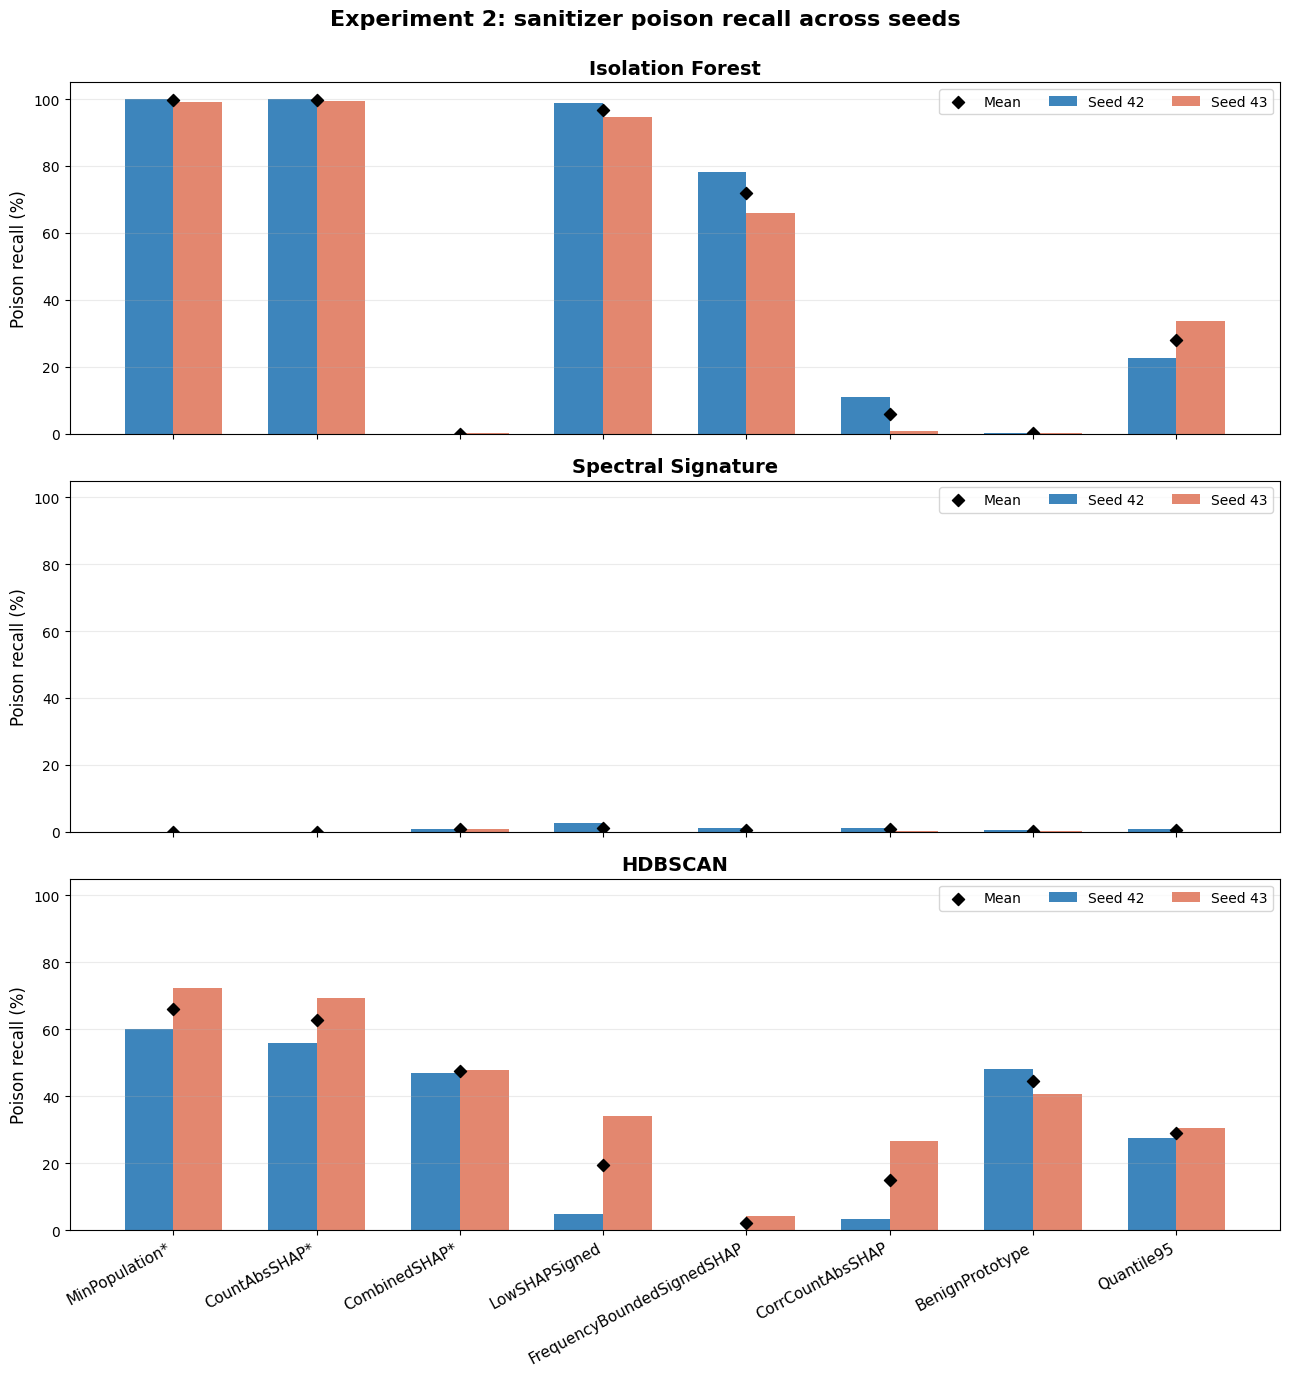

In [5]:
selector_order = [
    'MinPopulation*', 'CountAbsSHAP*', 'CombinedSHAP*',
    'LowSHAPSigned', 'FrequencyBoundedSignedSHAP',
    'CorrCountAbsSHAP', 'BenignPrototype', 'Quantile95',
]
sanitizer_order = ['Isolation Forest', 'Spectral Signature', 'HDBSCAN']
seed_colors = {42: '#2878B5', 43: '#E07A5F'}
fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True, sharey=True)
x = np.arange(len(selector_order))
width = 0.34
for ax, sanitizer in zip(axes, sanitizer_order):
    panel = seed_level[seed_level['sanitizer'] == sanitizer]
    for offset, seed in zip((-width / 2, width / 2), (42, 43)):
        values = panel[panel['seed'] == seed].set_index('selector')['poison_recall_percent'].reindex(selector_order)
        ax.bar(x + offset, values, width=width, color=seed_colors[seed], label=f'Seed {seed}', alpha=0.9)
    means = panel.groupby('selector')['poison_recall_percent'].mean().reindex(selector_order)
    ax.scatter(x, means, marker='D', s=38, color='black', label='Mean', zorder=5)
    ax.set_title(sanitizer, fontsize=14, fontweight='bold')
    ax.set_ylabel('Poison recall (%)', fontsize=12)
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='upper right', ncol=3, fontsize=10)
axes[-1].set_xticks(x, selector_order, rotation=28, ha='right', fontsize=11)
fig.suptitle('Experiment 2: sanitizer poison recall across seeds', fontsize=16, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.98))
for suffix in ('png', 'pdf'):
    fig.savefig(FIGURE_DIR / f'sanitizer_poison_recall_by_seed.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

## Matched Effectiveness and Detectability
This table joins ASR and sanitizer recall only for matching seeds 42 and 43. It avoids mixing the three-seed effectiveness average with the two-seed sanitizer average.

In [6]:
effectiveness_path = EXPORT_DIR / 'effectiveness_seed_level.csv'
effectiveness = pd.read_csv(effectiveness_path)
effectiveness = effectiveness[
    (effectiveness['dataset'] == 'EMBER2018')
    & (effectiveness['sampling'] == 'Random')
    & effectiveness['seed'].isin([42, 43])
][['seed', 'selector', 'asr_percent', 'backdoored_clean_accuracy_percent']]
matched = seed_level.merge(effectiveness, on=['seed', 'selector'], how='left', validate='many_to_one')
matched_summary = matched.groupby(['selector', 'source', 'sanitizer'], sort=False).agg(
    seeds=('seed', 'nunique'),
    asr_mean_percent=('asr_percent', 'mean'),
    asr_sd_percent=('asr_percent', 'std'),
    poison_recall_mean_percent=('poison_recall_percent', 'mean'),
    poison_recall_sd_percent=('poison_recall_percent', 'std'),
    removed_poisoned_mean=('removed_poisoned_rows', 'mean'),
    removed_clean_mean=('removed_clean_rows', 'mean'),
).reset_index()
display(matched_summary.round(2))

,selector,source,sanitizer,seeds,asr_mean_percent,asr_sd_percent,poison_recall_mean_percent,poison_recall_sd_percent,removed_poisoned_mean,removed_clean_mean
0,CountAbsSHAP*,Severi-derived,HDBSCAN,2,80.72,18.01,62.67,9.43,752.0,24780.0
1,BenignPrototype,This work,HDBSCAN,2,7.93,1.37,44.42,5.19,533.0,26134.5
2,CombinedSHAP*,Severi-derived,HDBSCAN,2,41.71,5.15,47.46,0.65,569.5,25842.5
3,CorrCountAbsSHAP,This work,HDBSCAN,2,47.82,9.81,14.92,16.62,179.0,25220.0
4,FrequencyBoundedSignedSHAP,This work,HDBSCAN,2,67.74,0.74,2.04,2.89,24.5,25568.0
5,LowSHAPSigned,This work,HDBSCAN,2,65.85,1.14,19.46,20.57,233.5,26892.0
6,MinPopulation*,Severi-derived,HDBSCAN,2,81.88,16.35,66.12,8.66,793.5,24348.5
7,Quantile95,This work,HDBSCAN,2,58.80,2.67,29.00,2.24,348.0,23615.5
8,CountAbsSHAP*,Severi-derived,Isolation Forest,2,80.72,18.01,99.75,0.35,1197.0,3.0
9,BenignPrototype,This work,Isolation Forest,2,7.93,1.37,0.08,0.00,1.0,1199.0


## Durable Exports
These files are compact and may be retained after deleting large attack arrays. They do **not** preserve row-level scores, removal indices, or the inputs needed to rerun sanitization or defense retraining.

In [7]:
summary.to_csv(EXPORT_DIR / 'sanitizer_metrics_mean_std_display.csv', index=False)
seed_level.to_csv(EXPORT_DIR / 'sanitizer_metrics_seed_level.csv', index=False)
aggregate.to_csv(EXPORT_DIR / 'sanitizer_metrics_mean_std.csv', index=False)
coverage.to_csv(EXPORT_DIR / 'sanitizer_coverage.csv', index=False)
(EXPORT_DIR / 'sanitizer_export_manifest.json').write_text(json.dumps(manifest, indent=2))
matched.to_csv(EXPORT_DIR / 'effectiveness_sanitizer_seed_level_matched.csv', index=False)
matched_summary.to_csv(EXPORT_DIR / 'effectiveness_sanitizer_mean_std_matched.csv', index=False)
print('Saved compact source tables in:', TABLE_DIR)
print('Saved notebook display tables in:', EXPORT_DIR)
print('Saved figures in:', FIGURE_DIR)

Saved compact source tables in: /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 2/tables/sanitizer_metrics
Saved notebook display tables in: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results/exports
Saved figures in: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results/figures
